In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("eda_dataset_v2.csv")

In [7]:
df = df.drop(columns=['location', 'notes'])

In [8]:
print("Missing values before cleaning:\n", df.isnull().sum())
df = df.dropna(subset=['text', 'category'])

# Keep only production categories (drop noisy/outlier labels)
VALID_CATEGORIES = {
    'education', 'emi', 'entertainment', 'food', 'friends',
    'healthcare', 'investment', 'shopping', 'travel', 'utilities'
}
df['category'] = df['category'].astype(str).str.strip().str.lower()
df = df[df['category'].isin(VALID_CATEGORIES)].copy()
print("Rows after category filter:", len(df))
print("Categories kept:", sorted(df['category'].unique().tolist()))

Missing values before cleaning:
 text                  27
amount                49
category               0
payment_method        16
payment_provider    9486
dtype: int64


In [9]:
df['amount'] = pd.to_numeric(df['amount'], errors='coerce')
# Remove negative amounts and NaNs
df = df[(df['amount'] > 0) & (df['amount'].notnull())]

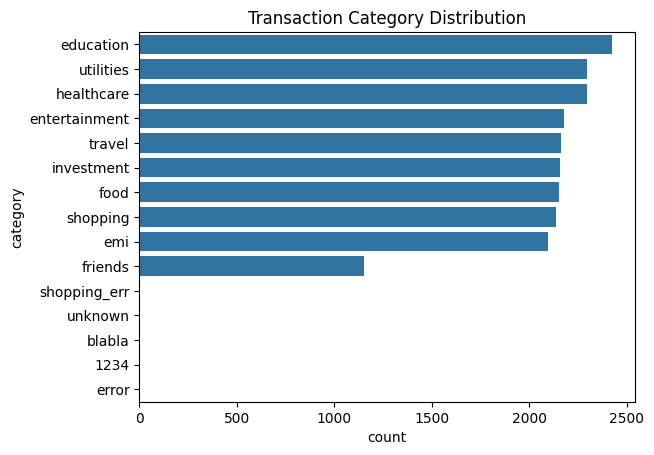

In [10]:
sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
plt.title("Transaction Category Distribution")
plt.show()

**Colab Code: Training DistilBERT for Category Classification**

In [11]:
!pip install transformers datasets evaluate

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Encode Categories (alphabetical order; keep this for inference LABEL_MAP)
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])
print('num_labels:', len(le.classes_))
print('classes:', list(le.classes_))

# 2. Split Data
train_df, val_df = train_test_split(df[['text', 'label']], test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# 3. Tokenization (Using DistilBERT - lightweight and fast)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_val = val_dataset.map(tokenize_function, batched=True)

# 4. Load Model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=len(le.classes_)
)

# 5. Train
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

trainer.train()

# 6. Export the Model Locally (or Download from Colab)
# This saves the model architecture, weights, and tokenizer files
model.save_pretrained("./my_finetuned_distilbert")
tokenizer.save_pretrained("./my_finetuned_distilbert")

# Zip it up so you can download it easily from Colab
!zip -r my_model.zip ./my_finetuned_distilbert


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  adding: my_finetuned_distilbert/ (stored 0%)
  adding: my_finetuned_distilbert/model.safetensors (deflated 8%)
  adding: my_finetuned_distilbert/tokenizer.json (deflated 71%)
  adding: my_finetuned_distilbert/config.json (deflated 61%)
  adding: my_finetuned_distilbert/tokenizer_config.json (deflated 42%)


** The Final Inference Pipeline**

In [12]:
import re
import torch

def extract_transaction_info(text):
    # 1. Predict Category (DistilBERT)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to('cuda')
    with torch.no_grad():
        outputs = model(**inputs)
    category_id = torch.argmax(outputs.logits, dim=1).item()
    category = le.inverse_transform([category_id])[0]

    # 2. Extract Amount (Regex & Multipliers)
    amount = None
    lower_text = text.lower()

    # Check for multiplier words (e.g. "do hazaar")
    multipliers = {"hazaar": 1000, "sau": 100, "lakh": 100000}
    for word, factor in multipliers.items():
        match = re.search(rf'(\d+\.?\d*)\s*{word}', lower_text)
        if match:
            amount = float(match.group(1)) * factor
            break

    # Fallback to standard numbers
    if not amount:
        numbers = re.findall(r'\b(\d[\d,]*\.?\d*)\b', lower_text)
        if numbers:
            amount = float(numbers[0].replace(',', ''))

    # 3. Extract Payment Method (Regex fallback to UX missing flag)
    payment_method = None
    if any(k in lower_text for k in ["upi", "gpay", "paytm", "phonepe", "bhim", "cred"]):
        payment_method = "upi"
    elif any(k in lower_text for k in ["card", "visa", "mastercard", "amex"]):
        payment_method = "card"
    elif any(k in lower_text for k in ["cash", "naqad", "nakd"]):
        payment_method = "cash"

    # 4. Extract Specific Bank Account (if mentioned)
    bank_account = None
    indian_banks = ["hdfc", "sbi", "icici", "axis", "kotak", "pnb", "bob", "yes bank", "idfc", "indusind"]
    for bank in indian_banks:
        if bank in lower_text:
            bank_account = bank
            break

    return {
        "text": text,
        "amount": amount,
        "category": category,
        "payment_method": payment_method,
        "bank_account": bank_account
    }

# Test the pipeline
print(extract_transaction_info("Bhai Swiggy se pizza mangwaya 450 rupaye ka, paid using hdfc"))
# Out: {'text': '...', 'amount': 450.0, 'category': 'food', 'payment_method': None, 'bank_account': 'hdfc'}
# ^ (Since payment is None, but bank_account is 'hdfc', the backend knows which account to deduct from,
# and can optionally prompt the user via WhatsApp to confirm if it was UPI or Card for that specific HDFC account)


{'text': 'Bhai Swiggy se pizza mangwaya 450 rupaye ka, paid using hdfc', 'amount': 450.0, 'category': 'food', 'payment_method': None, 'bank_account': 'hdfc'}
